In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
class Perceptron:

    def __init__(self, num_inputs, learning_rate=0.1):

        # Initialize weights randomly
        self.weights = np.random.randn(num_inputs)

        # Initialize bias
        self.bias = 0.0

        # Learning rate
        self.learning_rate = learning_rate


    # ---------------------------------
    # Step Function
    # ---------------------------------
    def activation(self, z):

        if z >= 0:
            return 1
        else:
            return 0


    # ---------------------------------
    # Prediction
    # ---------------------------------
    def predict(self, inputs):

        # Calculate weighted sum
        z = np.dot(inputs, self.weights) + self.bias

        # Apply activation function
        return self.activation(z)


    # ---------------------------------
    # Training
    # ---------------------------------
    def train(self, X, y, epochs=100):

        for epoch in range(epochs):

            for inputs, target in zip(X, y):

                # Make prediction
                prediction = self.predict(inputs)

                # Calculate error
                error = target - prediction

                # Update weights
                self.weights += (
                    self.learning_rate
                    * error
                    * inputs
                )

                # Update bias
                self.bias += (
                    self.learning_rate
                    * error
                )

In [3]:
# AND Gate Dataset

X_AND = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_AND = np.array([
    0,
    0,
    0,
    1
])

In [6]:
# Create AND perceptron

and_perceptron = Perceptron(
    num_inputs=2,
    learning_rate=0.1
)

# Train the model

and_perceptron.train(
    X_AND,
    y_AND,
    epochs=100
)

In [7]:
# Make predictions

and_predictions = []

for inputs in X_AND:

    prediction = and_perceptron.predict(inputs)

    and_predictions.append(prediction)


print("AND Predictions:")
print(and_predictions)

print("Actual Values:")
print(y_AND)

AND Predictions:
[0, 0, 0, 1]
Actual Values:
[0 0 0 1]


In [8]:
and_accuracy = np.mean(
    np.array(and_predictions) == y_AND
)

print(
    "AND Gate Accuracy:",
    and_accuracy * 100,
    "%"
)

AND Gate Accuracy: 100.0 %


In [9]:
# OR Gate Dataset

X_OR = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_OR = np.array([
    0,
    1,
    1,
    1
])

In [10]:
# Create OR perceptron

or_perceptron = Perceptron(
    num_inputs=2,
    learning_rate=0.1
)

# Train the model

or_perceptron.train(
    X_OR,
    y_OR,
    epochs=100
)

In [11]:
# Make predictions

or_predictions = []

for inputs in X_OR:

    prediction = or_perceptron.predict(inputs)

    or_predictions.append(prediction)


print("OR Predictions:")
print(or_predictions)

print("Actual Values:")
print(y_OR)

OR Predictions:
[0, 1, 1, 1]
Actual Values:
[0 1 1 1]


In [12]:
or_accuracy = np.mean(
    np.array(or_predictions) == y_OR
)

print(
    "OR Gate Accuracy:",
    or_accuracy * 100,
    "%"
)

OR Gate Accuracy: 100.0 %


In [13]:
learning_rate = 0.1
epochs = 100

In [14]:
and_perceptron.train(
    X_AND,
    y_AND,
    epochs=1000
)

In [15]:
# Generate a random linearly separable dataset

X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=2,
    cluster_std=2.0,
    random_state=42
)

print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Input Shape: (1000, 2)
Output Shape: (1000,)


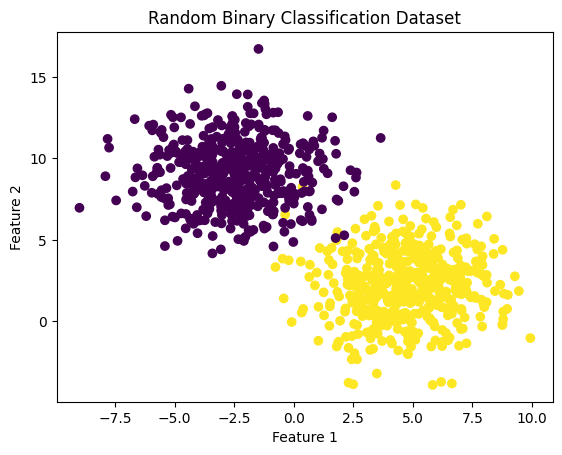

In [16]:
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title(
    "Random Binary Classification Dataset"
)

plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 800
Testing Samples: 200


In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [19]:
random_perceptron = Perceptron(
    num_inputs=2,
    learning_rate=0.01
)

In [20]:
random_perceptron.train(
    X_train,
    y_train,
    epochs=100
)

In [21]:
predictions = []

for inputs in X_test:

    prediction = random_perceptron.predict(inputs)

    predictions.append(prediction)

In [22]:
accuracy = np.mean(
    np.array(predictions) == y_test
)

print(
    "Model Accuracy:",
    accuracy * 100,
    "%"
)

Model Accuracy: 100.0 %


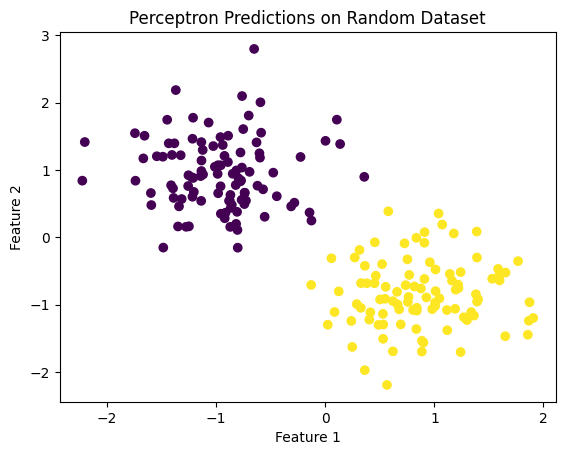

In [23]:
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=predictions
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title(
    "Perceptron Predictions on Random Dataset"
)

plt.show()